<a href="https://colab.research.google.com/github/sleepyarya/PCVK-SMT5/blob/main/Modul2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

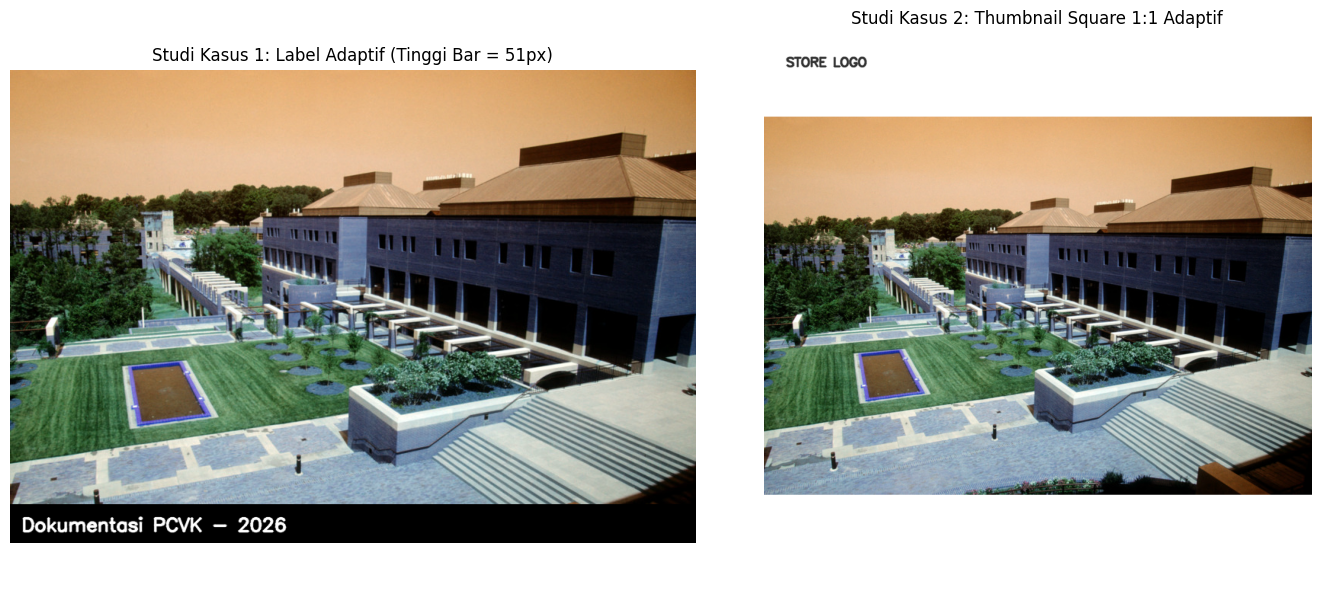

In [8]:
# MODUL 2 - TUGAS APLIKASI (STUDI KASUS 1 & 2)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# Ambil gambar uji dengan orientasi lanskap
url_landscape = "https://iiif.lib.ncsu.edu/iiif/0052574/full/900,/0/default.jpg"
img_landscape_raw = io.imread(url_landscape)
img_landscape = cv.cvtColor(img_landscape_raw, cv.COLOR_BGR2RGB)

# ==============================================================================
# STUDI KASUS 1: Label Identitas Adaptif pada Foto Dokumentasi
# ==============================================================================
def tambahkan_label_adaptif(img_input, teks="Dokumentasi PCVK - 2026"):
    img_out = img_input.copy()
    h, w = img_out.shape[:2]

    # 1. Hitung tinggi bar secara adaptif (tinggi_gambar // 12)
    bar_height = h // 12

    # 2. Gambar bar hitam di bagian bawah foto
    img_out[h - bar_height:h, 0:w] = [0, 0, 0]

    # 3. Hitung fontScale dan thickness secara adaptif dari lebar gambar
    font_scale = w / 900.0 * 0.8
    thickness = max(1, int(w / 450.0))
    font = cv.FONT_HERSHEY_SIMPLEX

    # 4. Tentukan posisi teks agar berada tepat di tengah bar bawah
    text_size, _ = cv.getTextSize(teks, font, font_scale, thickness)
    text_w, text_h = text_size
    text_x = 15  # Margin kiri
    text_y = h - (bar_height - text_h) // 2

    # 5. Tuliskan label teks
    cv.putText(img_out, teks, (text_x, text_y), font, font_scale, (255, 255, 255), thickness, cv.LINE_AA)
    return img_out, bar_height

# Jalankan Studi Kasus 1
img_labeled, bar_h = tambahkan_label_adaptif(img_landscape)

# ==============================================================================
# STUDI KASUS 2: Thumbnail Marketplace Persegi (1:1) Adaptif + Logo/Teks
# ==============================================================================
def buat_thumbnail_square(img_input, nama_toko="STORE LOGO"):
    h, w = img_input.shape[:2]
    max_dim = max(h, w)

    # 1. Buat kanvas putih persegi (max_dim x max_dim)
    canvas = np.full((max_dim, max_dim, 3), 255, dtype=np.uint8)

    # 2. Hitung offset koordinat agar citra terpasang tepat di tengah kanvas
    y_offset = (max_dim - h) // 2
    x_offset = (max_dim - w) // 2

    # 3. Tempelkan citra ke tengah kanvas
    canvas[y_offset:y_offset + h, x_offset:x_offset + w] = img_input

    # 4. Tambahkan logo/nama toko secara adaptif di pojok kiri atas kanvas
    font = cv.FONT_HERSHEY_SIMPLEX
    font_scale = max_dim / 800.0 * 0.6
    thickness = max(1, int(max_dim / 400.0))
    margin = int(max_dim * 0.04)

    cv.putText(canvas, nama_toko, (margin, margin + int(30 * font_scale)),
               font, font_scale, (50, 50, 50), thickness, cv.LINE_AA)

    return canvas

# Jalankan Studi Kasus 2
img_square = buat_thumbnail_square(img_landscape)

# ==============================================================================
# VISUALISASI HASIL STUDI KASUS 1 & 2
# ==============================================================================
plt.figure(figsize=(14, 6))

# Subplot Studi Kasus 1
plt.subplot(1, 2, 1)
plt.imshow(img_labeled)
plt.title(f"Studi Kasus 1: Label Adaptif (Tinggi Bar = {bar_h}px)")
plt.axis("off")

# Subplot Studi Kasus 2
plt.subplot(1, 2, 2)
plt.imshow(img_square)
plt.title("Studi Kasus 2: Thumbnail Square 1:1 Adaptif")
plt.axis("off")

plt.tight_layout()
plt.show()

- Pertanyaan Analisis:

Apakah proses mereduksi ukuran citra (downscaling) lalu mengembalikannya ke ukuran semula (upscaling) akan mengubah nilai rata-rata intensitas piksel dan menyebabkan kehilangan informasi detail?

Rancangan Program:Membaca citra asli dan menghitung rata-rata intensitas piksel serta standar deviasi aslinya.Mengecilkan citra hingga 25% dari ukuran asli menggunakan interpolasi INTER_AREA (downscaling).  Memperbesar kembali citra ke ukuran semula menggunakan interpolasi INTER_CUBIC (upscaling).  Menghitung kembali rata-rata intensitas piksel citra hasil rekonstruksi dan membandingkan selisihnya (Mean Squared Error / MSE) dengan citra asli.

=== DATA HASIL ANALISIS ===
Ukuran Asli          : 800 x 552 px
Ukuran Downscaling   : 200 x 138 px
Rata-rata Intensitas Asli         : 119.0049
Rata-rata Intensitas Rekonstruksi : 119.0187
Selisih Rata-rata (Delta Mean)    : 0.0138
Nilai Error Detail (MSE)          : 182.5747


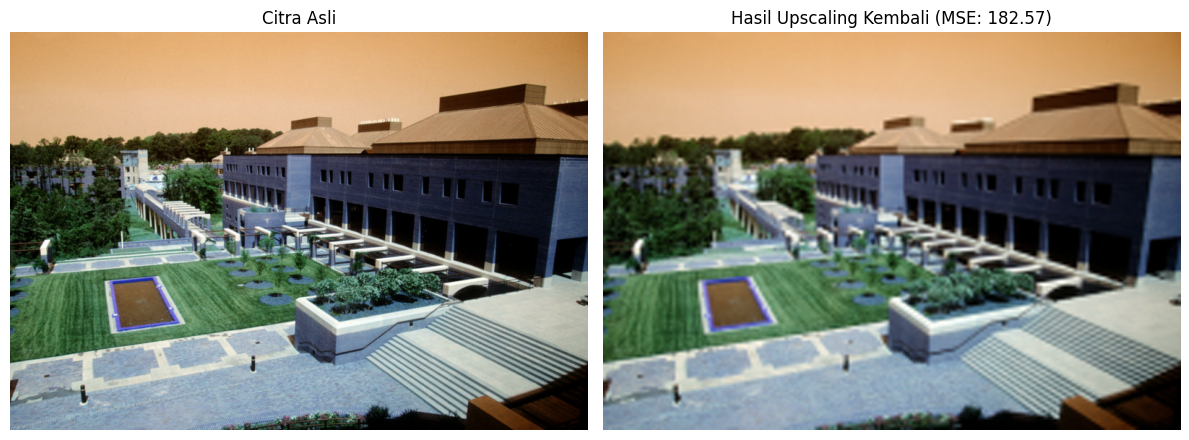

In [9]:
# TUGAS PRAKTIKUM - ANALISA

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# 1. Ambil citra uji
url_aktif = "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg"
img_raw = io.imread(url_aktif)
img_rgb = cv.cvtColor(img_raw, cv.COLOR_BGR2RGB)

# 2. Hitung statistik citra asli
mean_asli = np.mean(img_rgb)
std_asli = np.std(img_rgb)

# 3. Downscaling (pengecilan ke 25%)
h_ori, w_ori = img_rgb.shape[:2]
img_small = cv.resize(img_rgb, (w_ori // 4, h_ori // 4), interpolation=cv.INTER_AREA)

# 4. Upscaling (pembesaran kembali ke ukuran asli)
img_reconstructed = cv.resize(img_small, (w_ori, h_ori), interpolation=cv.INTER_CUBIC)

# 5. Hitung statistik citra hasil rekonstruksi
mean_rek = np.mean(img_reconstructed)
std_rek = np.std(img_reconstructed)

# 6. Hitung tingkat kerusakan/perubahan detail (Mean Squared Error)
mse = np.mean((img_rgb.astype("float") - img_reconstructed.astype("float")) ** 2)

# Tampilkan data hasil statistik
print("=== DATA HASIL ANALISIS ===")
print(f"Ukuran Asli          : {w_ori} x {h_ori} px")
print(f"Ukuran Downscaling   : {w_ori // 4} x {h_ori // 4} px")
print(f"Rata-rata Intensitas Asli         : {mean_asli:.4f}")
print(f"Rata-rata Intensitas Rekonstruksi : {mean_rek:.4f}")
print(f"Selisih Rata-rata (Delta Mean)    : {abs(mean_asli - mean_rek):.4f}")
print(f"Nilai Error Detail (MSE)          : {mse:.4f}")

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_reconstructed)
plt.title(f"Hasil Upscaling Kembali (MSE: {mse:.2f})")
plt.axis("off")

plt.tight_layout()
plt.show()

- Kesimpulan Analisis:
Rata-rata intensitas piksel secara keseluruhan hanya mengalami perubahan yang sangat kecil/diabaikan (selisih rata-rata dekat $0$), karena proses interpolasi meratakan nilai piksel tetangga. Namun, proses ini tetap menyebabkan kehilangan detail informasi berfrekuensi tinggi (tepi dan tekstur halus) secara permanen, yang terbukti dari nilai MSE yang signifikan serta tampilan visual citra hasil rekonstruksi yang menjadi lebih kabur (blurry).

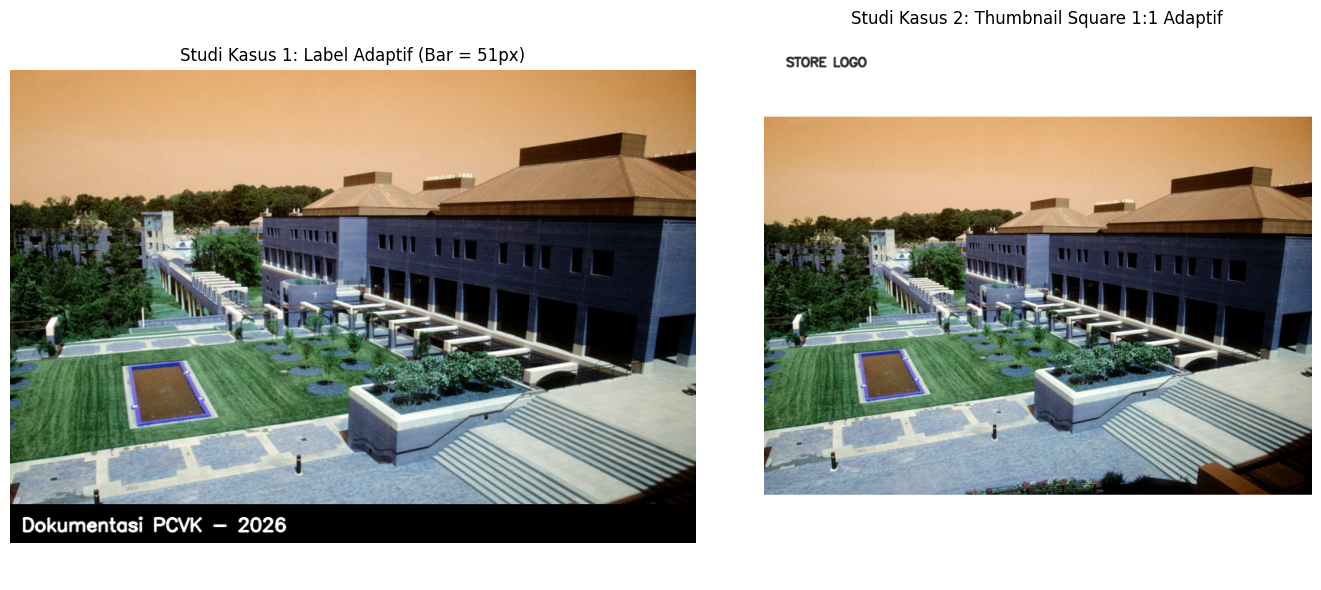

In [10]:
# TUGAS PRAKTIKUM - APLIKASI (STUDI KASUS 1 & 2)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# Ambil gambar uji dari URL
url_landscape = "https://iiif.lib.ncsu.edu/iiif/0052574/full/900,/0/default.jpg"
img_landscape_raw = io.imread(url_landscape)
img_landscape = cv.cvtColor(img_landscape_raw, cv.COLOR_BGR2RGB)

# ==============================================================================
# STUDI KASUS 1: Label Identitas Adaptif pada Foto Dokumentasi
# ==============================================================================
def tambahkan_label_adaptif(img_input, teks="Dokumentasi PCVK - 2026"):
    img_out = img_input.copy()
    h, w = img_out.shape[:2]

    # 1. Tinggi bar dihitung adaptif (h // 12)
    bar_height = h // 12

    # 2. Gambar bar hitam di bagian bawah foto
    img_out[h - bar_height:h, 0:w] = [0, 0, 0]

    # 3. Ukuran font & ketebalan dihitung adaptif dari lebar gambar
    font_scale = w / 900.0 * 0.8
    thickness = max(1, int(w / 450.0))
    font = cv.FONT_HERSHEY_SIMPLEX

    # 4. Tentukan posisi teks di tengah bar bawah
    text_size, _ = cv.getTextSize(teks, font, font_scale, thickness)
    text_w, text_h = text_size
    text_x = 15  # Margin kiri
    text_y = h - (bar_height - text_h) // 2

    # 5. Tuliskan label teks
    cv.putText(img_out, teks, (text_x, text_y), font, font_scale, (255, 255, 255), thickness, cv.LINE_AA)
    return img_out, bar_height

# ==============================================================================
# STUDI KASUS 2: Thumbnail Marketplace Persegi 1:1 Adaptif + Logo Store
# ==============================================================================
def buat_thumbnail_square(img_input, nama_toko="STORE LOGO"):
    h, w = img_input.shape[:2]
    max_dim = max(h, w)

    # 1. Buat kanvas putih persegi (max_dim x max_dim)
    canvas = np.full((max_dim, max_dim, 3), 255, dtype=np.uint8)

    # 2. Hitung offset agar gambar tepat di tengah kanvas
    y_offset = (max_dim - h) // 2
    x_offset = (max_dim - w) // 2

    # 3. Tempelkan gambar ke kanvas
    canvas[y_offset:y_offset + h, x_offset:x_offset + w] = img_input

    # 4. Tambahkan logo/nama toko secara adaptif di pojok kiri atas
    font = cv.FONT_HERSHEY_SIMPLEX
    font_scale = max_dim / 800.0 * 0.6
    thickness = max(1, int(max_dim / 400.0))
    margin = int(max_dim * 0.04)

    cv.putText(canvas, nama_toko, (margin, margin + int(30 * font_scale)),
               font, font_scale, (50, 50, 50), thickness, cv.LINE_AA)

    return canvas

# Eksekusi Fungsi
img_labeled, bar_h = tambahkan_label_adaptif(img_landscape)
img_square = buat_thumbnail_square(img_landscape)

# Visualisasi
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_labeled)
plt.title(f"Studi Kasus 1: Label Adaptif (Bar = {bar_h}px)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_square)
plt.title("Studi Kasus 2: Thumbnail Square 1:1 Adaptif")
plt.axis("off")

plt.tight_layout()
plt.show()

- Studi Kasus 1 (Label Dokumentasi Adaptif):
 1. Tinggi bar hitam dihitung proporsional dari tinggi gambar ($h / 12$).
 2. Ukuran font (font_scale) dan ketebalan garis (thickness) dihitung dari lebar gambar ($w$), sehingga proporsi tulisan tetap seimbang di foto beresolusi berapa pun
- Studi Kasus 2 (Thumbnail Marketplace 1:1 Adaptif):
 1. Kanvas putih dibentuk dari dimensi terbesar $\max(h, w)$.
 2. Gambar asli terpasang di tengah kanvas (centering offset) tanpa merusak rasio aspek.
 3. Teks logo toko ditempatkan secara otomatis menggunakan margin berbasis persen dari ukuran kanvas